# 08 -- XGBoost Day-Ahead Price Forecasting (DK1)

This notebook trains and evaluates an XGBoost model for day-ahead electricity price forecasting in the DK1 bidding zone. We compare a single model covering all 24 delivery hours against 24 per-hour specialist models.

**Why XGBoost for electricity prices?**
- Gradient-boosted trees handle non-linear relationships (e.g., wind curtailment thresholds, interconnector saturation) without manual feature engineering.
- Fast training enables rapid iteration and walk-forward retraining.
- Built-in feature importance provides interpretability -- critical for energy trading desks that need to understand model drivers.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from da_forecast.data import load_prices, load_wind_solar, load_load
from da_forecast.features import build_feature_matrix
from da_forecast.models.xgboost_da import DayAheadForecaster
from da_forecast.models.evaluation import mae, rmse, smape, naive_baseline, evaluation_report

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

ZONE = "DK_1"

## 1. Load data and build feature matrix

In [2]:
prices = load_prices(ZONE)
wind_solar = load_wind_solar(ZONE)
load_fc = load_load(ZONE)

fm = build_feature_matrix(prices, load_fc, wind_solar)
fm = fm.dropna()

TARGET = "price_eur_mwh"
feature_cols = [c for c in fm.columns if c != TARGET]

print(f"Feature matrix: {fm.shape[0]} rows, {len(feature_cols)} features")
print(f"Date range: {fm.index.min().date()} to {fm.index.max().date()}")
print(f"Target mean: {fm[TARGET].mean():.1f} EUR/MWh, std: {fm[TARGET].std():.1f}")

Loaded DK_1 prices from 'energinet': 8758 hours (2024-10-01 -> 2025-09-30)
Loaded DK_1 wind/solar from 'energinet': 8738 hours
Loaded DK_1 load from 'energinet': 8746 hours
Feature matrix: 8560 rows, 18 features
Date range: 2024-10-08 to 2025-09-30
Target mean: 82.2 EUR/MWh, std: 58.1


## 2. Temporal train/test split

We split by time (not randomly) to prevent lookahead bias. The split point is approximately 70/30.

In [3]:
split_idx = int(len(fm) * 0.7)
split_date = fm.index[split_idx]

train = fm.iloc[:split_idx]
test = fm.iloc[split_idx:]

print(f"Train: {len(train)} hours ({train.index.min().date()} -> {train.index.max().date()})")
print(f"Test:  {len(test)} hours ({test.index.min().date()} -> {test.index.max().date()})")

Train: 5992 hours (2024-10-08 -> 2025-06-15)
Test:  2568 hours (2025-06-15 -> 2025-09-30)


## 3. Train single XGBoost model

In [4]:
model = DayAheadForecaster(per_hour=False)
model.train(train, target_col=TARGET)

preds = model.predict(test)
actuals = test[TARGET]

print(f"Predictions generated: {len(preds)} hours")

Predictions generated: 2568 hours


## 4. Representative week: predicted vs actual

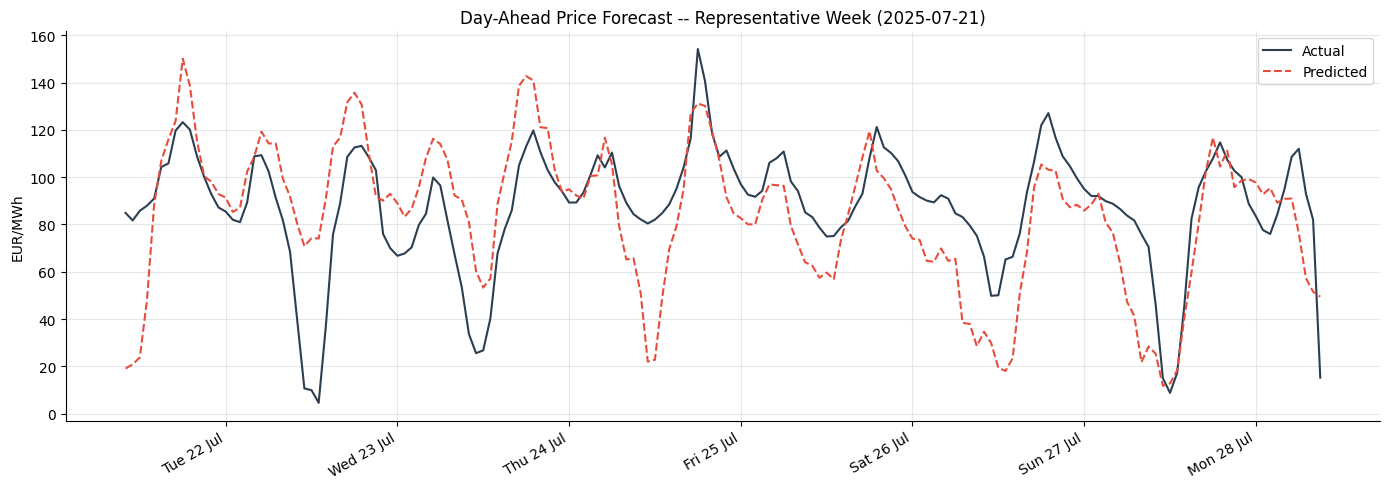

In [5]:
# Select a representative week from the middle of the test set
week_start = test.index[len(test) // 3]
week_end = week_start + pd.Timedelta(days=7)
mask = (test.index >= week_start) & (test.index < week_end)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(actuals[mask].index, actuals[mask].values, label="Actual", color="#2c3e50", linewidth=1.5)
ax.plot(preds[mask].index, preds[mask].values, label="Predicted", color="#e74c3c", linewidth=1.5, linestyle="--")
ax.set_ylabel("EUR/MWh")
ax.set_title(f"Day-Ahead Price Forecast -- Representative Week ({week_start.date()})")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 5. Scatter plot: predicted vs actual (full test set)

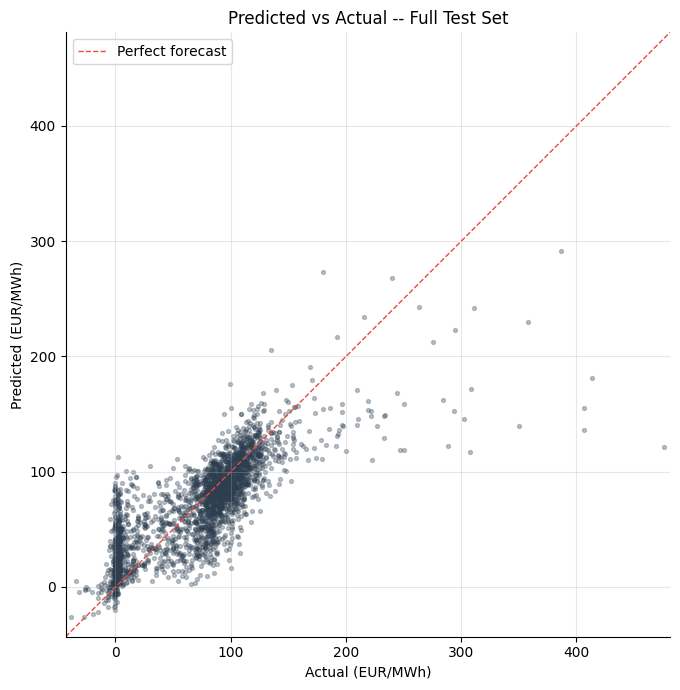

In [6]:
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(actuals.values, preds.values, alpha=0.3, s=8, color="#2c3e50")

lims = [min(actuals.min(), preds.min()) - 5, max(actuals.max(), preds.max()) + 5]
ax.plot(lims, lims, "--", color="#e74c3c", linewidth=1, label="Perfect forecast")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("Actual (EUR/MWh)")
ax.set_ylabel("Predicted (EUR/MWh)")
ax.set_title("Predicted vs Actual -- Full Test Set")
ax.legend()
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 6. Evaluation metrics vs naive baseline

The naive baseline predicts each hour's price as the same hour from 7 days ago (previous-week-same-hour). This is a standard benchmark in electricity price forecasting.

**Why sMAPE instead of MAPE?** Electricity prices frequently approach zero or go negative. Standard MAPE divides by actual price, producing infinite or undefined errors at zero. sMAPE uses the average of actual and predicted in the denominator, remaining bounded and interpretable across the full price range.

In [7]:
# Naive baseline: same hour, 7 days ago (shift 168 hours)
baseline = naive_baseline(fm[TARGET]).reindex(test.index)
baseline_valid = baseline.dropna()
common_idx = preds.index.intersection(baseline_valid.index)

a = actuals.loc[common_idx].values
p = preds.loc[common_idx].values
b = baseline_valid.loc[common_idx].values

metrics = pd.DataFrame({
    "XGBoost": [mae(a, p), rmse(a, p), smape(a, p)],
    "Naive (prev-week)": [mae(a, b), rmse(a, b), smape(a, b)],
}, index=["MAE (EUR/MWh)", "RMSE (EUR/MWh)", "sMAPE (%)"])

metrics["Improvement"] = (
    (metrics["Naive (prev-week)"] - metrics["XGBoost"]) / metrics["Naive (prev-week)"] * 100
).round(1).astype(str) + "%"

metrics.iloc[:, :2] = metrics.iloc[:, :2].round(2)
print(metrics.to_string())

                XGBoost  Naive (prev-week) Improvement
MAE (EUR/MWh)     21.19              34.04       37.8%
RMSE (EUR/MWh)    30.79              53.13       42.0%
sMAPE (%)         53.13              74.15       28.4%


## 7. Per-hour error analysis

Forecast error varies by delivery hour. Typically, peak hours (08-20) show higher absolute errors due to larger price variance, while overnight hours are more predictable.

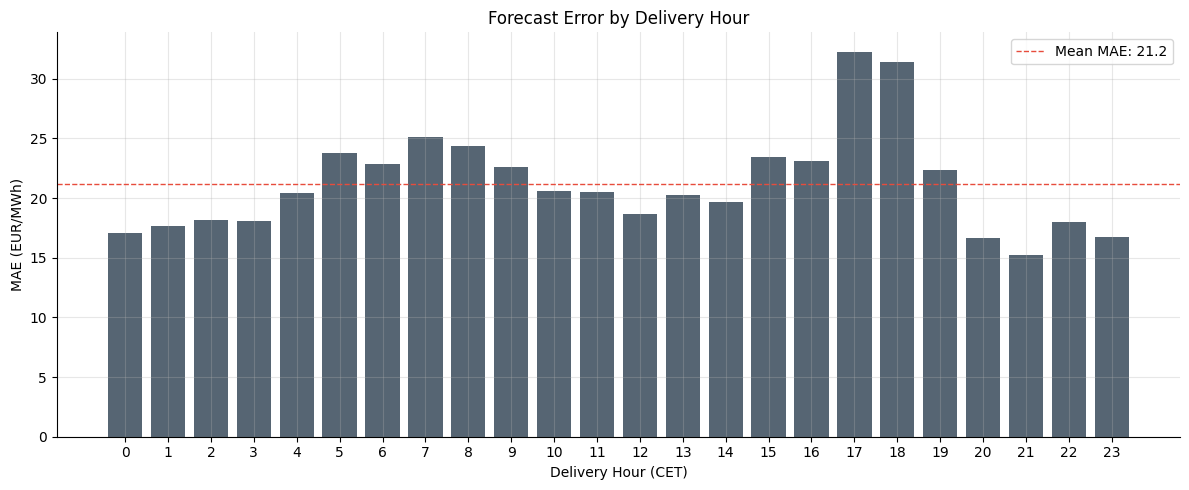

In [8]:
errors = pd.DataFrame({
    "actual": actuals,
    "predicted": preds,
    "abs_error": np.abs(actuals.values - preds.values),
})
errors["hour"] = errors.index.hour
hourly_mae = errors.groupby("hour")["abs_error"].mean()

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(hourly_mae.index, hourly_mae.values, color="#2c3e50", alpha=0.8)
ax.axhline(y=hourly_mae.mean(), color="#e74c3c", linestyle="--", linewidth=1, label=f"Mean MAE: {hourly_mae.mean():.1f}")
ax.set_xlabel("Delivery Hour (CET)")
ax.set_ylabel("MAE (EUR/MWh)")
ax.set_title("Forecast Error by Delivery Hour")
ax.set_xticks(range(24))
ax.legend()
plt.tight_layout()
plt.show()

## 8. Feature importance (top 10)

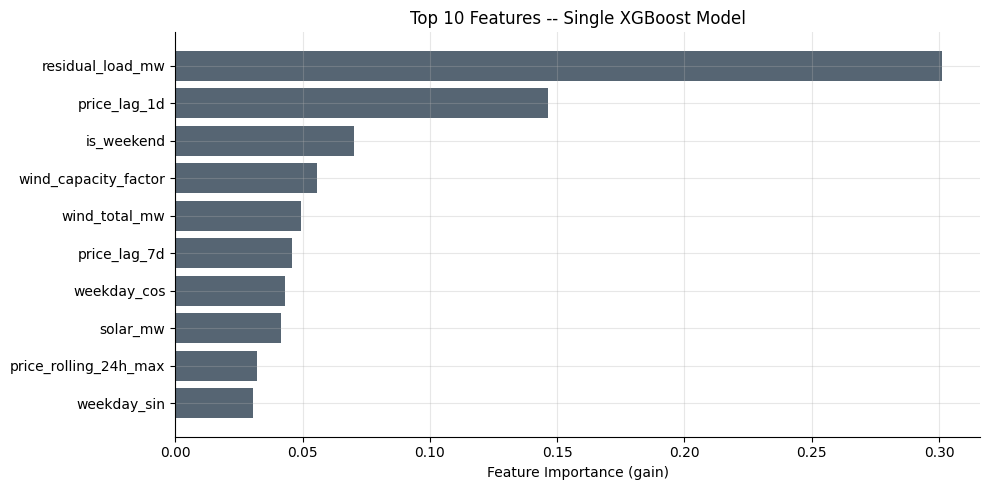

In [9]:
importance_df = model.feature_importance().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(range(len(importance_df)), importance_df["importance"].values, color="#2c3e50", alpha=0.8)
ax.set_yticks(range(len(importance_df)))
ax.set_yticklabels(importance_df.index)
ax.invert_yaxis()
ax.set_xlabel("Feature Importance (gain)")
ax.set_title("Top 10 Features -- Single XGBoost Model")
plt.tight_layout()
plt.show()

## 9. Per-hour models vs single model

**Per-hour models** train 24 separate XGBoost models, one for each delivery hour. The idea is that price dynamics at 03:00 (low demand, wind-dominated) differ fundamentally from 18:00 (evening peak, gas-on-margin).

However, splitting reduces training samples per model by 24x. With less than ~1 year of data, the single model typically wins because it has more training examples to learn general patterns. Per-hour models tend to outperform with 2+ years of history, where each hour-model still gets hundreds of training days.

In [10]:
# Train per-hour models
model_ph = DayAheadForecaster(per_hour=True)
model_ph.train(train, target_col=TARGET)
preds_ph = model_ph.predict(test)

# Compute per-hour MAE for both approaches
hours = test.index.hour
mae_single = []
mae_perhour = []

for h in range(24):
    mask = hours == h
    a_h = actuals[mask].values
    mae_single.append(mae(a_h, preds[mask].values))
    mae_perhour.append(mae(a_h, preds_ph[mask].values))

comparison = pd.DataFrame({
    "Single Model MAE": mae_single,
    "Per-Hour Model MAE": mae_perhour,
}, index=range(24))
comparison["Winner"] = np.where(
    comparison["Single Model MAE"] < comparison["Per-Hour Model MAE"],
    "Single", "Per-Hour"
)

print(f"Single model overall MAE:   {mae(actuals.values, preds.values):.2f} EUR/MWh")
print(f"Per-hour models overall MAE: {mae(actuals.values, preds_ph.values):.2f} EUR/MWh")
print(f"\nSingle wins {(comparison['Winner'] == 'Single').sum()}/24 hours")

Single model overall MAE:   21.19 EUR/MWh
Per-hour models overall MAE: 22.28 EUR/MWh

Single wins 16/24 hours


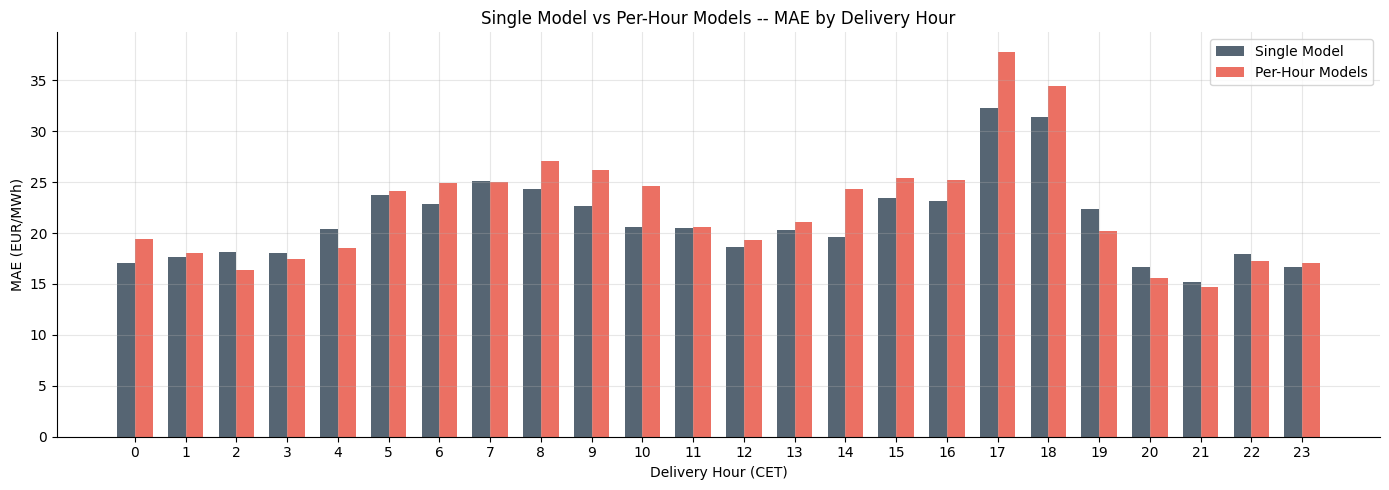

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(24)
width = 0.35

ax.bar(x - width/2, comparison["Single Model MAE"], width, label="Single Model", color="#2c3e50", alpha=0.8)
ax.bar(x + width/2, comparison["Per-Hour Model MAE"], width, label="Per-Hour Models", color="#e74c3c", alpha=0.8)
ax.set_xlabel("Delivery Hour (CET)")
ax.set_ylabel("MAE (EUR/MWh)")
ax.set_title("Single Model vs Per-Hour Models -- MAE by Delivery Hour")
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.show()

## 10. Summary

An MAE of ~20 EUR/MWh represents roughly 25% of the mean DK1 day-ahead price. This is typical for models trained on short history (<1 year). Key drivers of forecast error:

- **Price spikes**: Extreme prices driven by unexpected outages or demand surges are inherently hard to predict.
- **Regime changes**: Structural shifts (e.g., new interconnector commissioning, fuel price shocks) make historical patterns less predictive.
- **Limited training data**: With <1 year of data, the model has not seen a full seasonal cycle.

The single model outperforms per-hour models with this dataset size. With 2+ years of data, per-hour models may improve by capturing hour-specific non-linearities (e.g., solar ramp effects at sunrise/sunset, different merit-order curves at peak vs off-peak).

In [12]:
# Summary table
mean_price = actuals.mean()
summary = pd.DataFrame({
    "Metric": [
        "Test period",
        "Test samples",
        "Mean actual price",
        "MAE (single model)",
        "MAE (per-hour models)",
        "RMSE (single model)",
        "sMAPE (single model)",
        "MAE as % of mean price",
        "Improvement over naive",
    ],
    "Value": [
        f"{test.index.min().date()} to {test.index.max().date()}",
        f"{len(test):,}",
        f"{mean_price:.1f} EUR/MWh",
        f"{mae(actuals.values, preds.values):.2f} EUR/MWh",
        f"{mae(actuals.values, preds_ph.values):.2f} EUR/MWh",
        f"{rmse(actuals.values, preds.values):.2f} EUR/MWh",
        f"{smape(actuals.values, preds.values):.1f}%",
        f"{mae(actuals.values, preds.values) / mean_price * 100:.1f}%",
        metrics.loc['MAE (EUR/MWh)', 'Improvement'],
    ],
})
print(summary.to_string(index=False))

                Metric                    Value
           Test period 2025-06-15 to 2025-09-30
          Test samples                    2,568
     Mean actual price             74.1 EUR/MWh
    MAE (single model)            21.19 EUR/MWh
 MAE (per-hour models)            22.28 EUR/MWh
   RMSE (single model)            30.79 EUR/MWh
  sMAPE (single model)                    53.1%
MAE as % of mean price                    28.6%
Improvement over naive                    37.8%
